# ☕ EDA — Coffee Quality Classification
### Proyecto Grupal — Clasificación de Calidad de Café

---

## 📖 ¿Qué es un EDA y para qué sirve?

El **Análisis Exploratorio de Datos (EDA)** es el primer paso de todo proyecto de Machine Learning.  
Antes de entrenar cualquier modelo, necesitamos **entender** los datos:
- ¿Qué hay en el dataset?
- ¿Los datos están limpios o tienen errores?
- ¿Qué variables son importantes?
- ¿Hay patrones o relaciones entre variables?

**Analogía:** El EDA es como leer el manual de instrucciones antes de montar un mueble. Puedes saltártelo, pero luego te sobran tornillos.

---

## 🗺️ Hoja de Ruta del Notebook

| Bloque | Qué vamos a hacer |
|--------|-------------------|
| **0** | Importar librerías y cargar datos |
| **1** | Primera inspección del dataset |
| **2** | Análisis de valores nulos |
| **3** | Crear la variable objetivo (target) |
| **4** | Análisis de variables numéricas (sensoriales) |
| **5** | Análisis de variables categóricas (origen, proceso) |
| **6** | Correlaciones entre variables |
| **7** | Detección de outliers |
| **8** | Exportación de modelos |

---

> ⚠️ **Importante:** Ejecuta las celdas en orden, de arriba a abajo. Cada celda depende de la anterior.

---
## 📦 BLOQUE 0 — Importar librerías y cargar el dataset
  
- `pandas` → manipular tablas de datos  
- `numpy` → cálculos matemáticos  
- `matplotlib` y `seaborn` → crear gráficos  
- `warnings` → ocultar avisos que no nos interesan

In [1]:
# ─── Librerías ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración visual global (Gráficos consistentes en estilo y tamaño)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [2]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/coffee_quality_fusion.csv')

print(f'✅ Dataset cargado correctamente')
print(f'📊 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Dataset cargado correctamente
📊 Dimensiones: 1512 filas x 38 columnas


---
## 🔍 BLOQUE 1 — Primera inspección del dataset

**Objetivo:** Entender qué hay dentro del dataset sin entrar en detalles todavía. Es como abrir una caja y ver qué hay dentro antes de sacar nada.

**Preguntas que vamos a responder:**
- ¿Cuántas filas y columnas tiene?
- ¿Qué significa cada columna?
- ¿Qué tipo de dato tiene cada columna (número, texto, fecha)?

**¿Cómo lo haremos?**

Usar .head(), .tail(), .info() y .describe() es el estándar para una primera inspección. El .tail() es valioso porque verifica que los datos no se cortaron al final (un error común al cargar CSVs grandes).

In [3]:
# Ver las primeras 5 filas del dataset
print('📋 Primeras 5 filas del dataset:')
df.head()

📋 Primeras 5 filas del dataset:


,Acidity,Aftertaste,Aroma,Bag Weight,Balance,Body,Category One Defects,Category Two Defects,Certification Address,Certification Body,...,Processing Method,Producer,Quakers,Region,Sweetness,Total Cup Points,Uniformity,Variety,altitud_limpia,dataset_source
0,8.75,8.67,8.67,60 kg,8.42,8.50,0,0,309fcf77415a3661ae83e027f7e5f05dad786e44,METAD Agricultural Development plc,...,Washed / Wet,METAD PLC,0.0,guji-hambela,10.0,90.58,10.0,NaN,2075.0,2018_volpatto
1,8.58,8.50,8.75,60 kg,8.42,8.42,0,1,309fcf77415a3661ae83e027f7e5f05dad786e44,METAD Agricultural Development plc,...,Washed / Wet,METAD PLC,0.0,guji-hambela,10.0,89.92,10.0,Other,2075.0,2018_volpatto
2,8.42,8.42,8.42,1,8.42,8.33,0,0,36d0d00a3724338ba7937c52a378d085f2172daa,Specialty Coffee Association,...,NaN,NaN,0.0,NaN,10.0,89.75,10.0,Bourbon,1700.0,2018_volpatto
3,8.42,8.42,8.17,60 kg,8.25,8.50,0,2,309fcf77415a3661ae83e027f7e5f05dad786e44,METAD Agricultural Development plc,...,Natural / Dry,Yidnekachew Dabessa Coffee Plantation,0.0,oromia,10.0,89.00,10.0,NaN,2000.0,2018_volpatto
4,8.50,8.25,8.25,60 kg,8.33,8.42,0,2,309fcf77415a3661ae83e027f7e5f05dad786e44,METAD Agricultural Development plc,...,Washed / Wet,METAD PLC,0.0,guji-hambela,10.0,88.83,10.0,Other,2075.0,2018_volpatto


In [4]:
# Ver las últimas 5 filas
print('📋 Últimas 5 filas del dataset:')
df.tail()

📋 Últimas 5 filas del dataset:


,Acidity,Aftertaste,Aroma,Bag Weight,Balance,Body,Category One Defects,Category Two Defects,Certification Address,Certification Body,...,Processing Method,Producer,Quakers,Region,Sweetness,Total Cup Points,Uniformity,Variety,altitud_limpia,dataset_source
1507,7.17,6.92,7.17,60 kg,7.17,7.42,0,4,"Rua Gaspar Batista Paiva, 416 – Santa Luiza Va...",Brazil Specialty Coffee Association,...,Natural / Dry,Ipanema Coffees,0.0,Sul de Minas,10.0,80.08,10.0,Mundo Novo,950.0,2023_fatihb
1508,7.17,6.75,7.33,30 kg,7.17,7.42,0,12,"Del Hotel Seminole 2 C al lago, 1 C arriba.",Asociación de Cafés Especiales de Nicaragua,...,Natural / Dry,Exportadora Atlantic S.A.,2.0,Matagalpa,10.0,80.00,10.0,Shg,1200.0,2023_fatihb
1509,7.00,7.08,7.25,60 kg,7.08,7.08,0,11,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",Japan Coffee Exchange,...,Washed / Wet,"LAO MINH TIEN COFFEE SOLE CO.,LTD",9.0,Bolaven Plateau,10.0,79.67,10.0,Catimor,1300.0,2023_fatihb
1510,7.17,6.75,6.50,2 kg,7.00,7.08,0,13,"Final 1a. Av. Norte y 13 Calle Pte., dentro de...",Salvadoran Coffee Council,...,Natural / Dry,Roselia Yglesias,12.0,"Volcan de San Vicente, La Paz, El Salvador",10.0,78.08,10.0,Maragogype,1200.0,2023_fatihb
1511,6.83,6.67,7.25,60 kg,6.67,6.83,0,1,"Instituto de Ecología A. C., Campus III Edific...",Centro Agroecológico del Café A.C.,...,Semi-Lavado,Walter Matter,0.0,Minas Gerais,10.0,78.00,10.0,Mundo Novo,975.0,2023_fatihb


Los datos podemos dividirlo en tres grupos:
* Metadata: No útiles en predicción (Company, Farm name)
* Sensoriales: Las más valiosas del modelo (Aroma, Flavor)
* Físicas/proceso: Complemento a estudio. (Altitude, Country)

In [5]:
# Información general del dataset
print('ℹ️ Información del dataset:')
df.info()

ℹ️ Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Acidity                1512 non-null   float64
 1   Aftertaste             1512 non-null   float64
 2   Aroma                  1512 non-null   float64
 3   Bag Weight             1512 non-null   str    
 4   Balance                1512 non-null   float64
 5   Body                   1512 non-null   float64
 6   Category One Defects   1512 non-null   int64  
 7   Category Two Defects   1512 non-null   int64  
 8   Certification Address  1512 non-null   str    
 9   Certification Body     1512 non-null   str    
 10  Certification Contact  1512 non-null   str    
 11  Clean Cup              1512 non-null   float64
 12  Color                  1246 non-null   str    
 13  Company                1303 non-null   str    
 14  Country of Origin      1511 non-null   

In [6]:
# Estadísticas descriptivas de las columnas numéricas
print('📊 Estadísticas descriptivas:')
df.describe().round(2)

📊 Estadísticas descriptivas:


,Acidity,Aftertaste,Aroma,Balance,Body,Category One Defects,Category Two Defects,Clean Cup,Flavor,Moisture Percentage,Number of Bags,Overall,Quakers,Sweetness,Total Cup Points,Uniformity,altitud_limpia
count,1512.00,1512.00,1512.00,1512.00,1512.00,1512.00,1512.00,1512.00,1512.00,1512.00,1512.00,1512.00,1511.00,1512.00,1512.00,1512.00,1252.00
mean,7.55,7.43,7.59,7.53,7.53,0.39,3.41,9.86,7.55,1.55,154.31,7.52,0.25,9.92,82.33,9.85,1320.22
std,0.37,0.40,0.37,0.39,0.35,1.72,5.12,0.72,0.39,3.69,150.57,0.46,1.02,0.50,3.38,0.52,420.17
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00
25%,7.33,7.25,7.42,7.33,7.33,0.00,0.00,10.00,7.33,0.10,10.00,7.33,0.00,10.00,81.42,10.00,1100.00
50%,7.58,7.42,7.58,7.58,7.50,0.00,2.00,10.00,7.58,0.11,149.00,7.50,0.00,10.00,82.67,10.00,1320.00
75%,7.75,7.67,7.75,7.75,7.75,0.00,4.00,10.00,7.75,0.12,275.00,7.75,0.00,10.00,83.83,10.00,1600.00
max,8.75,8.67,8.75,8.75,8.58,31.00,55.00,10.00,8.83,13.50,2240.00,10.00,12.00,10.00,90.58,10.00,3500.00


Las estadísticas descriptivas nos revelan:
- `Uniformity` tiene casi todos los valores en ~10. Variable con varianza casi nula.
- `Sweetness` lo mismo con sus datos ~10. Varianza casi nula.
- `Clean cup` valores similares
- `altitud_limpia` altitud normalizada y el rango restringido por valores imposibles.

In [7]:
# Ver el nombre de todas las columnas disponibles 
# (útil para trabajar en el DataFrame)
print('Columnas disponibles en el dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:02d}. {col}')

Columnas disponibles en el dataset:
  01. Acidity
  02. Aftertaste
  03. Aroma
  04. Bag Weight
  05. Balance
  06. Body
  07. Category One Defects
  08. Category Two Defects
  09. Certification Address
  10. Certification Body
  11. Certification Contact
  12. Clean Cup
  13. Color
  14. Company
  15. Country of Origin
  16. Expiration
  17. Farm Name
  18. Flavor
  19. Grading Date
  20. Harvest Year
  21. ICO Number
  22. In-Country Partner
  23. Lot Number
  24. Mill
  25. Moisture Percentage
  26. Number of Bags
  27. Overall
  28. Owner
  29. Processing Method
  30. Producer
  31. Quakers
  32. Region
  33. Sweetness
  34. Total Cup Points
  35. Uniformity
  36. Variety
  37. altitud_limpia
  38. dataset_source


### 📌 ¿Qué significan las columnas más importantes?

| Columna | Significado | Tipo |
|---------|-------------|------|
| `Country of Origin` | País donde se cultivó el café | Categórica |
| `Variety` | Variedad de la planta de café | Categórica |
| `Processing Method` | Método de procesado del grano (Washed, Natural, Honey) | Categórica |
| `altitude_limpia` | Altitud de cultivo en metros ya regularizada | Numérica |
| `Aroma` | Puntuación de aroma (0-10) | Numérica |
| `Flavor` | Puntuación de sabor (0-10) | Numérica |
| `Aftertaste` | Puntuación de regusto (0-10) | Numérica |
| `Acidity` | Puntuación de acidez (0-10) | Numérica |
| `Body` | Puntuación de cuerpo/textura (0-10) | Numérica |
| `Balance` | Puntuación de balance general (0-10) | Numérica |
| `Uniformity` | Uniformidad de la taza (0-10) | Numérica |
| `Sweetness` | Dulzura del café (0-10) | Numérica |
| `Category One Defects` | Número de defectos graves del lote | Numérica |
| `Category Two Defects` | Número de defectos leves del lote | Numérica |

---
## 🕳️ BLOQUE 2 — Análisis de valores nulos

Analizamos los valores nulos (NaN = Not a Number), que ocurre cuando la información no estaba disponible o no se registró.

**¿Por qué importa?**  
Los modelos de ML no pueden trabajar con valores vacíos. Tenemos que decidir qué hacer con ellos:  
- **Eliminar** la fila o columna  
- **Rellenar** con un valor (media, mediana, moda)

**Regla general:**  
- Si una columna tiene `> 40% nulos` → considerar eliminarla  
- Si tiene `< 40% nulos` → rellenar (imputar)

In [8]:
# Contar valores nulos por columna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': pct_nulos
}).sort_values('Porcentaje (%)', ascending=False)

resumen_nulos[resumen_nulos['Valores Nulos'] > 0]


,Valores Nulos,Porcentaje (%)
Lot Number,1039,68.72
Farm Name,358,23.68
Mill,313,20.70
ICO Number,277,18.32
Color,266,17.59
altitud_limpia,260,17.20
Producer,231,15.28
Company,209,13.82
Variety,206,13.62
Processing Method,156,10.32


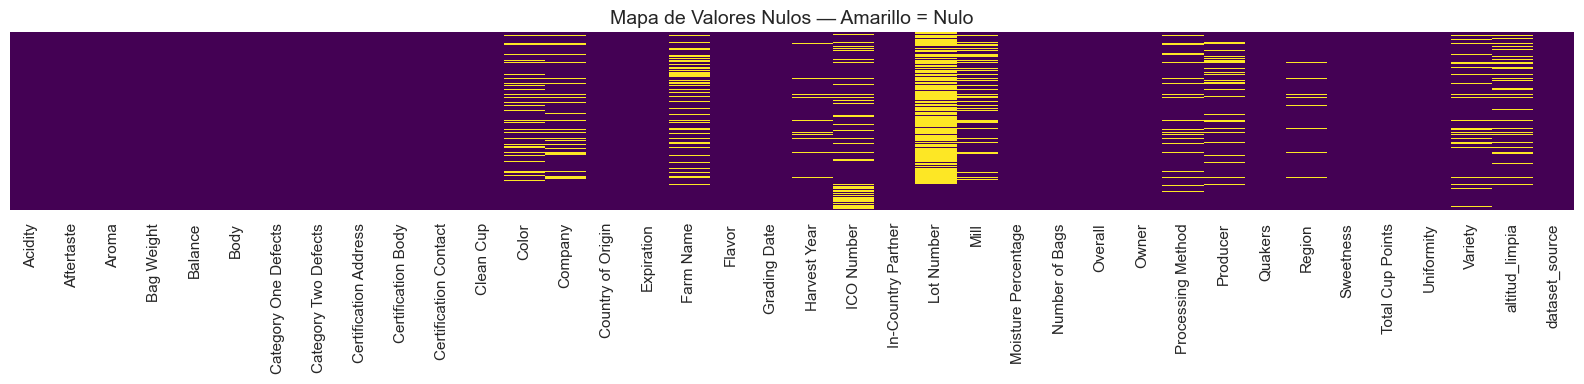


📊 Total de celdas vacías: 3429
📊 Porcentaje de nulos sobre el total: 5.97%


In [9]:
# Visualizar los nulos con un heatmap
# Las zonas amarillas = nulos
plt.figure(figsize=(16, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Valores Nulos — Amarillo = Nulo', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\n📊 Total de celdas vacías: {df.isnull().sum().sum()}')
print(f'📊 Porcentaje de nulos sobre el total: {(df.isnull().sum().sum() / df.size * 100):.2f}%')

In [10]:
# ─── DECISIÓN: Qué columnas eliminar ─────────────────────────────────────────
# Estas columnas son metadata (identificadores, nombres) que no aportan al modelo
# 📌 ACCIÓN: Revisa esta lista y ajusta según lo que veas en tu dataset

columnas_a_eliminar = [
    'ID',
    'Owner',
    'Farm Name',
    'Lot Number',
    'Mill',
    'ICO Number',
    'Company',
    'In-Country Partner',
    'Producer',
    'Bag Weight',
    'Number of Bags',
    'Expiration',
    'Certification Body',
    'Certification Address',
    'Certification Contact',
    'Overall'
]

# Filtrar solo las que existen en nuestro dataset
columnas_a_eliminar = [c for c in columnas_a_eliminar if c in df.columns]

df_clean = df.drop(columns=columnas_a_eliminar)
print(f'✅ Columnas eliminadas: {len(columnas_a_eliminar)}')
print(f'📊 Dimensiones nuevas: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas')

✅ Columnas eliminadas: 15
📊 Dimensiones nuevas: 1512 filas x 23 columnas


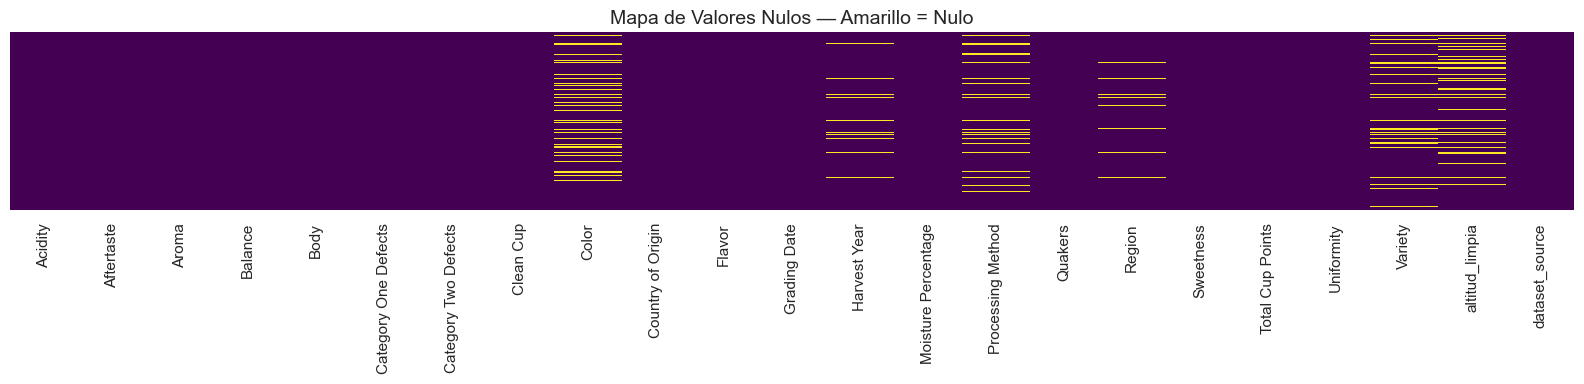


📊 Total de celdas vacías: 995
📊 Porcentaje de nulos sobre el total: 2.86%


In [11]:
# Visualizar los nuevos nulos con un heatmap

plt.figure(figsize=(16, 4))
sns.heatmap(df_clean.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Valores Nulos — Amarillo = Nulo', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\n📊 Total de celdas vacías: {df_clean.isnull().sum().sum()}')
print(f'📊 Porcentaje de nulos sobre el total: {(df_clean.isnull().sum().sum() / df_clean.size * 100):.2f}%')

---
## 🎯 BLOQUE 3 — Crear la variable objetivo (TARGET)

En nuestro caso es la variable que queremos predecir. Si un lote de café es **Specialty** o **No Specialty**.

**¿Cómo lo creamos?**  
Usamos el un valor un poco mas estricto que el estándar oficial de la **Specialty Coffee Association (SCA)**:  
- `Total Cup Points >= 82.5` → **Specialty** (calidad premium)  
- `Total Cup Points < 82.5` → **No Specialty** (calidad estándar)

**⚠️ MUY IMPORTANTE:**  
Después de crear el target, debemos **eliminar `Total Cup Points` del dataset**, para evitar hacer (data leakage) porque el target viene directamente de esa columna.

In [12]:
# Crear la columna target usando el umbral de la SCA
UMBRAL_SPECIALTY = 82.5

# Usando una función anónima para simplificar el código
df_clean['quality_label'] = df_clean['Total Cup Points'].apply(
    lambda x: 'Specialty' if x >= UMBRAL_SPECIALTY else 'No Specialty'
)   

print('✅ Variable target creada: quality_label')
print(f'\nUmbral utilizado: {UMBRAL_SPECIALTY} puntos (estándar SCA)')
print('\nDistribución del target:')
print(df_clean['quality_label'].value_counts())
print(f'\nEn porcentaje:')
print(df_clean['quality_label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

✅ Variable target creada: quality_label

Umbral utilizado: 82.5 puntos (estándar SCA)

Distribución del target:
quality_label
Specialty       834
No Specialty    678
Name: count, dtype: int64

En porcentaje:
quality_label
Specialty       55.16%
No Specialty    44.84%
Name: proportion, dtype: str


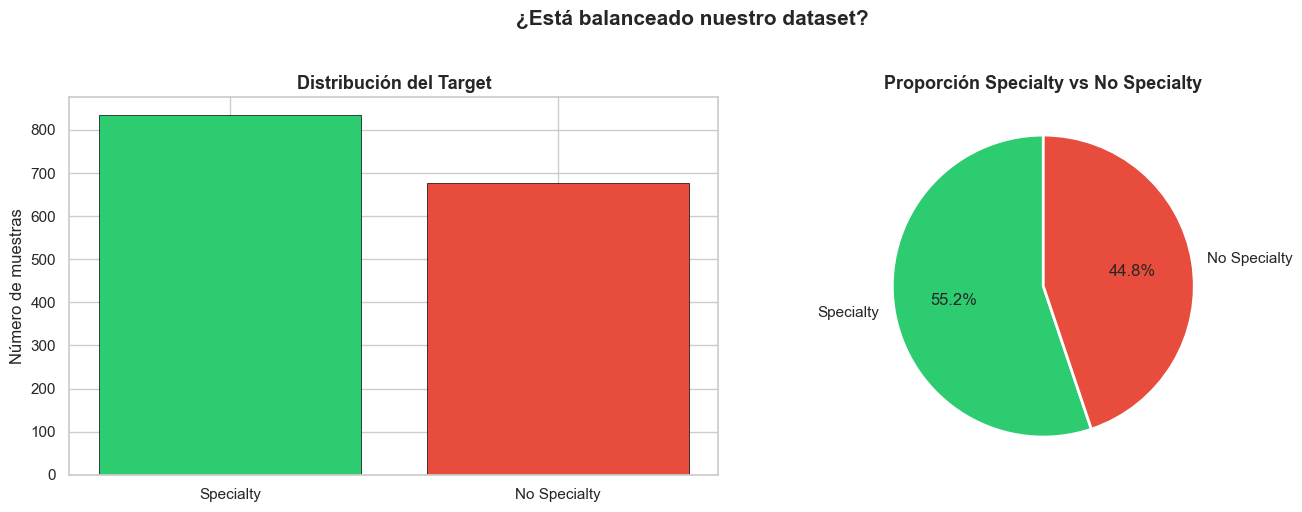

In [13]:
# Visualizar la distribución del target

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
conteo = df_clean['quality_label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(conteo.index, conteo.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribución del Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de muestras')

# Gráfico circular
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción Specialty vs No Specialty', fontsize=13, fontweight='bold')

plt.suptitle('¿Está balanceado nuestro dataset?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



In [14]:
# Eliminamos Total Cup Points para evitar data leakage
if 'Total Cup Points' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Total Cup Points'])
print('\n⚠️  Total Cup Points eliminado del dataset')


⚠️  Total Cup Points eliminado del dataset


---
## 📊 BLOQUE 4 — Análisis de variables numéricas (sensoriales)

**Objetivo:** Entender cómo se distribuyen las puntuaciones sensoriales y si hay diferencias entre cafés Specialty y No Specialty.

**¿Qué vamos a ver?**
- **Histograma:** Distribución de cada puntuación ¿es normal? ¿está sesgada?
- **Boxplot:** Comparación entre categorías de calidad
- **Violinplot:** Distribución completa por categoría

In [15]:
# Definir las columnas sensoriales que vamos a analizar

variables_sensoriales = [
    'Aroma', 'Flavor', 'Aftertaste', 'Acidity',
    'Body', 'Balance', 'Uniformity', 'Sweetness'
]

# Filtrar solo las que existen en nuestro dataset
variables_sensoriales = [v for v in variables_sensoriales if v in df_clean.columns]

print(f'Variables sensoriales encontradas: {variables_sensoriales}')

Variables sensoriales encontradas: ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Sweetness']


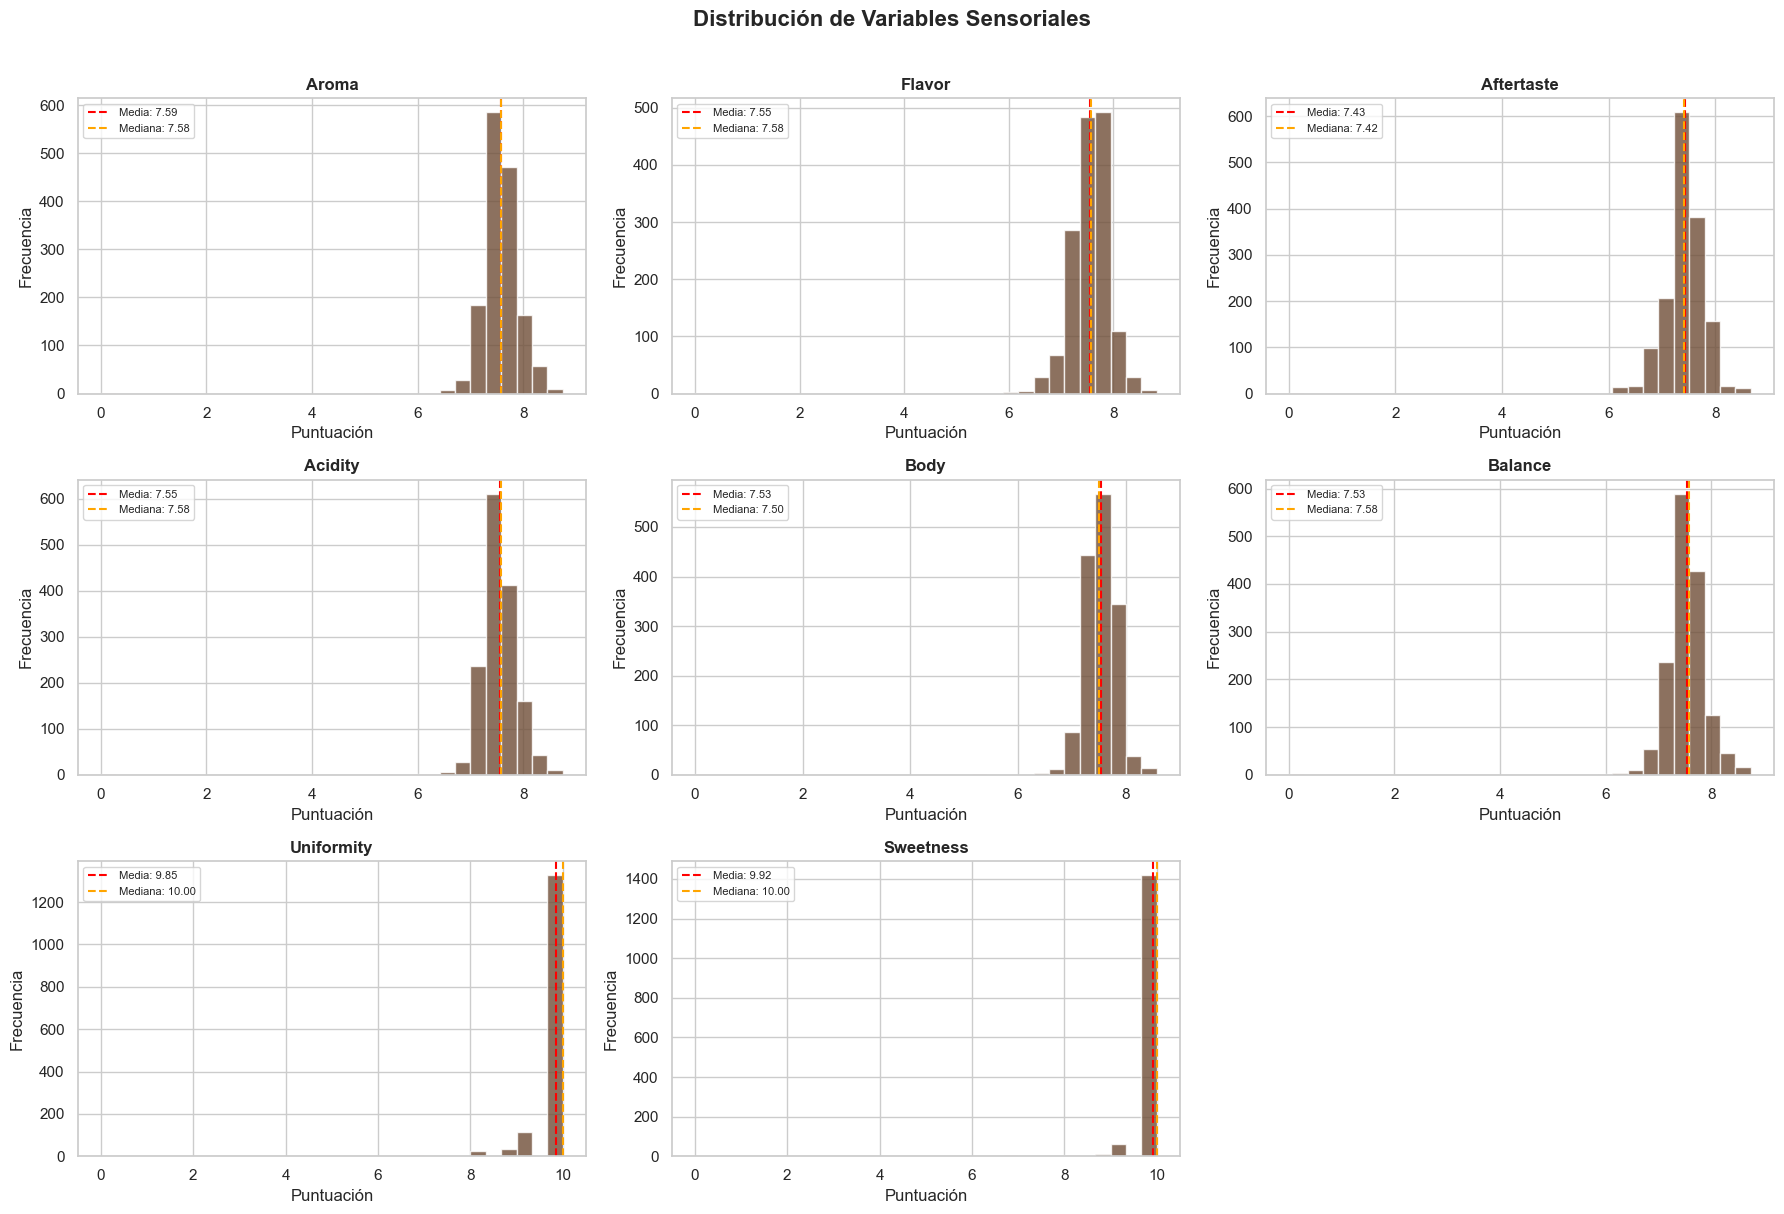

In [19]:
# ─── HISTOGRAMAS ──────────────────────────────────────────────────────────────
# Un histograma muestra cuántas muestras hay en cada rango de valores
# Ideal: distribución en forma de campana (normal)
# Si está muy sesgada hacia un lado, puede indicar outliers

n_cols = 3
n_rows = (len(variables_sensoriales) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables_sensoriales):
    axes[i].hist(df_clean[var].dropna(), bins=30, color='#6f4e37', edgecolor='white', alpha=0.8)
    axes[i].axvline(df_clean[var].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df_clean[var].mean():.2f}')
    axes[i].axvline(df_clean[var].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df_clean[var].median():.2f}')
    axes[i].set_title(f'{var}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Puntuación')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

# Ocultar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Sensoriales', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Las puntuaciones se concentran entre 7.5 y 8.5 para la mayoría de variables, lo cual confirma que el dataset corresponde a cafés de alta calidad en general (Competición de café de especialidad).

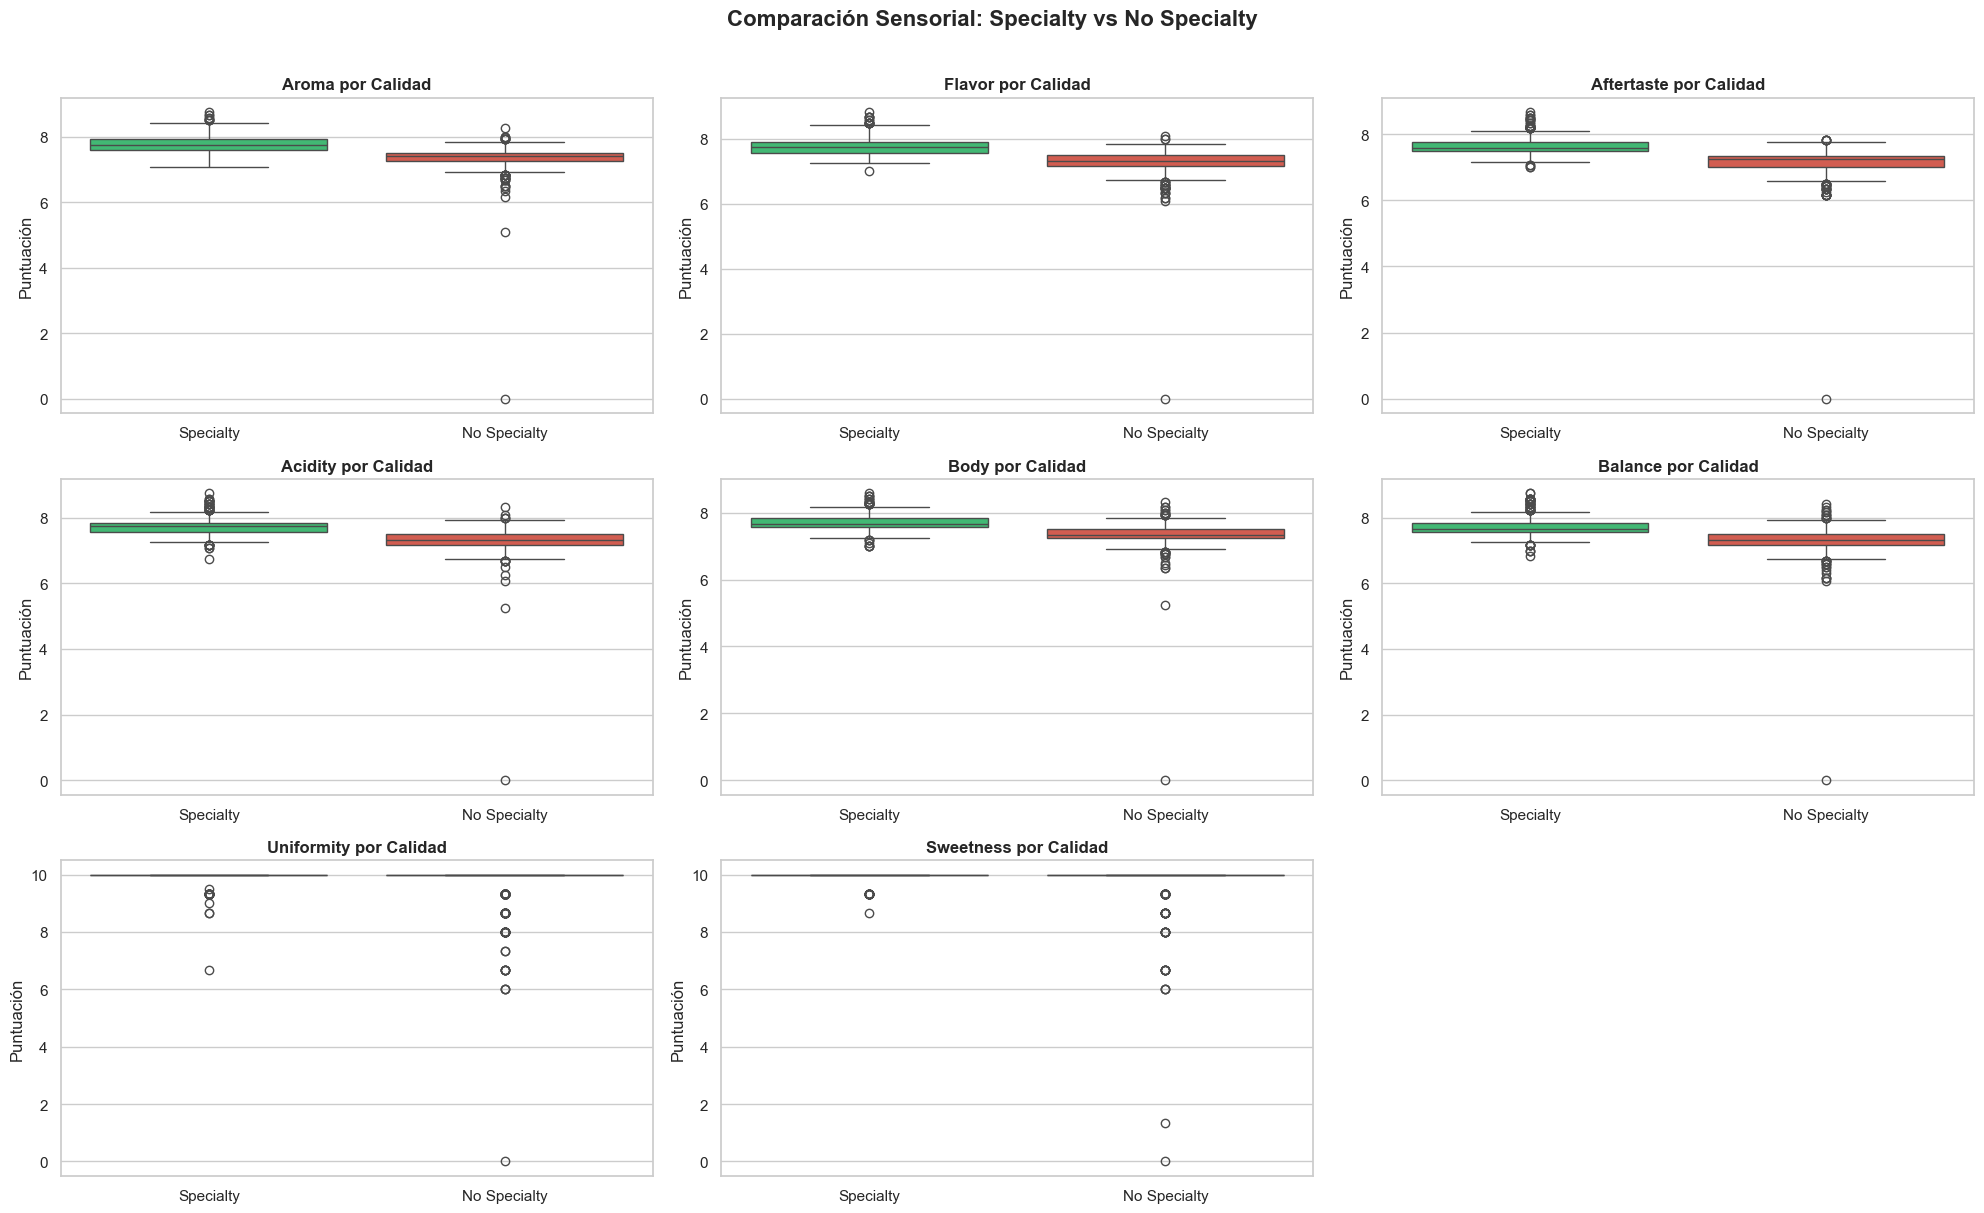

In [20]:
# ─── BOXPLOTS POR CALIDAD ─────────────────────────────────────────────────────
# Un boxplot muestra:
#   - La caja = donde está el 50% de los datos (Q1 a Q3)
#   - La línea en el medio = mediana
#   - Los puntos fuera = outliers

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

palette = {'Specialty': '#2ecc71', 'No Specialty': '#e74c3c'}

for i, var in enumerate(variables_sensoriales):
    sns.boxplot(
        data=df_clean, x='quality_label', y=var,
        palette=palette, ax=axes[i], order=['Specialty', 'No Specialty']
    )
    axes[i].set_title(f'{var} por Calidad', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Puntuación')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Comparación Sensorial: Specialty vs No Specialty', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Esta es la visualización más valiosa del bloque. Si los boxplots están claramente separados entre categorías, esa variable tiene poder discriminante o sea, le será útil al modelo para clasificar. Si se solapan completamente, la variable no distingue bien entre clases.

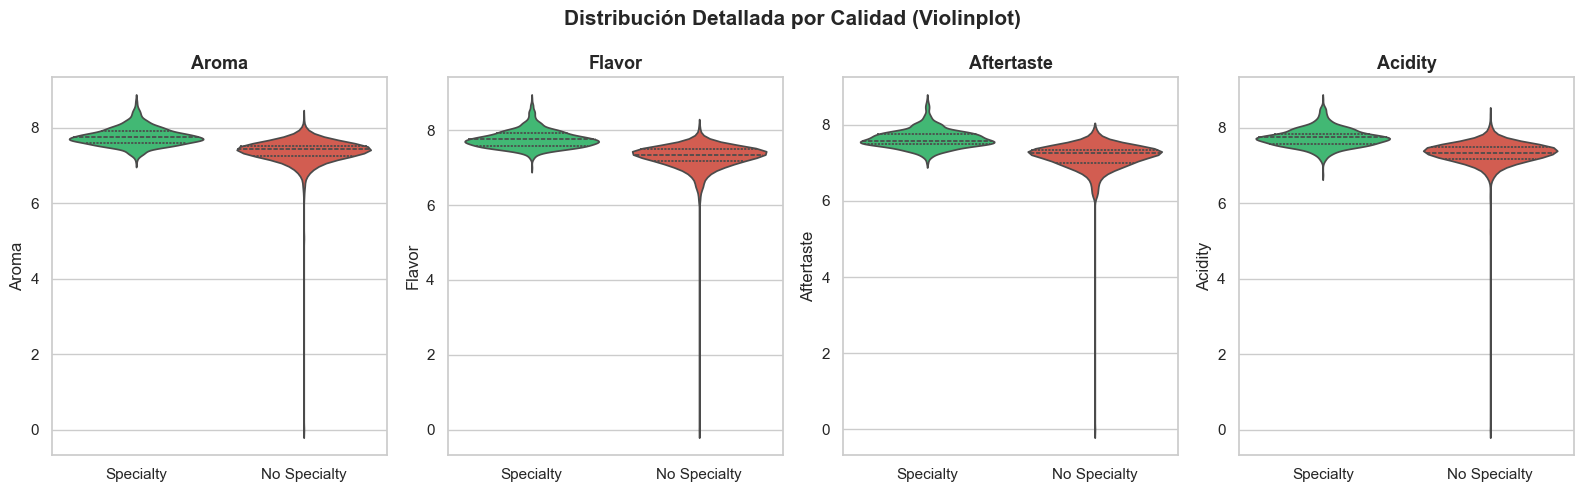

In [22]:
# ─── VIOLINPLOT DE LAS VARIABLES MÁS IMPORTANTES ────────────────────────────
# El violinplot combina el boxplot con la distribución real de los datos

top_vars = variables_sensoriales[:4]  # Las 4 primeras como ejemplo

fig, axes = plt.subplots(1, len(top_vars), figsize=(16, 5))

for i, var in enumerate(top_vars):
    sns.violinplot(
        data=df_clean, x='quality_label', y=var,
        palette=palette, ax=axes[i], inner='quartile',
        order=['Specialty', 'No Specialty']
    )
    axes[i].set_title(f'{var}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Distribución Detallada por Calidad (Violinplot)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Información sobre la forma de la distribución, no solo los cuartiles. Un violín asimétrico o bimodal revela patrones que el boxplot no muestra.

---
## 🌍 BLOQUE 5 — Análisis de variables categóricas

**Variables categóricas:** Son las que tienen texto, como el país de origen, la variedad o el método de procesado.

**Objetivo:** Entender si el origen o el proceso del café influye en la calidad final.

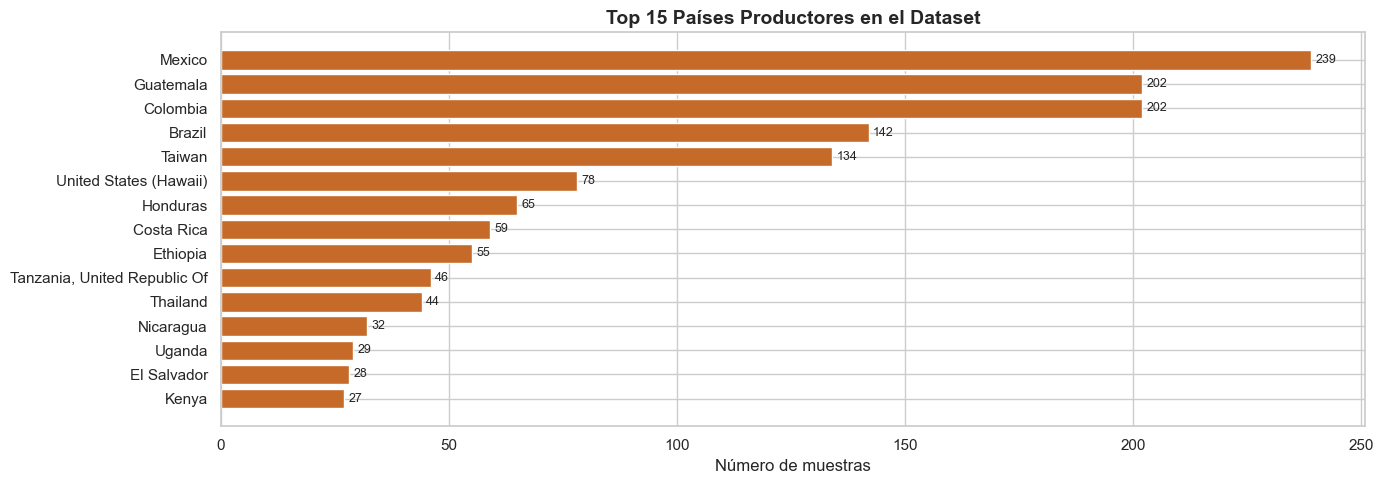

In [ ]:
# ─── ANÁLISIS POR PAÍS DE ORIGEN ─────────────────────────────────────────────
# ¿Qué países producen más cafés Specialty?

col_pais = 'Country of Origin'

if col_pais in df_clean.columns:
    # Top 15 países con más muestras
    top_paises = df_clean[col_pais].value_counts().head(15)

    plt.figure(figsize=(14, 5))
    bars = plt.barh(top_paises.index[::-1], top_paises.values[::-1],
                    color="#c56a29", edgecolor='white')
    plt.xlabel('Número de muestras')
    plt.title('Top 15 Países Productores en el Dataset', fontsize=14, fontweight='bold')

    for bar, val in zip(bars, top_paises.values[::-1]):
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
        
    plt.tight_layout()
    plt.show()

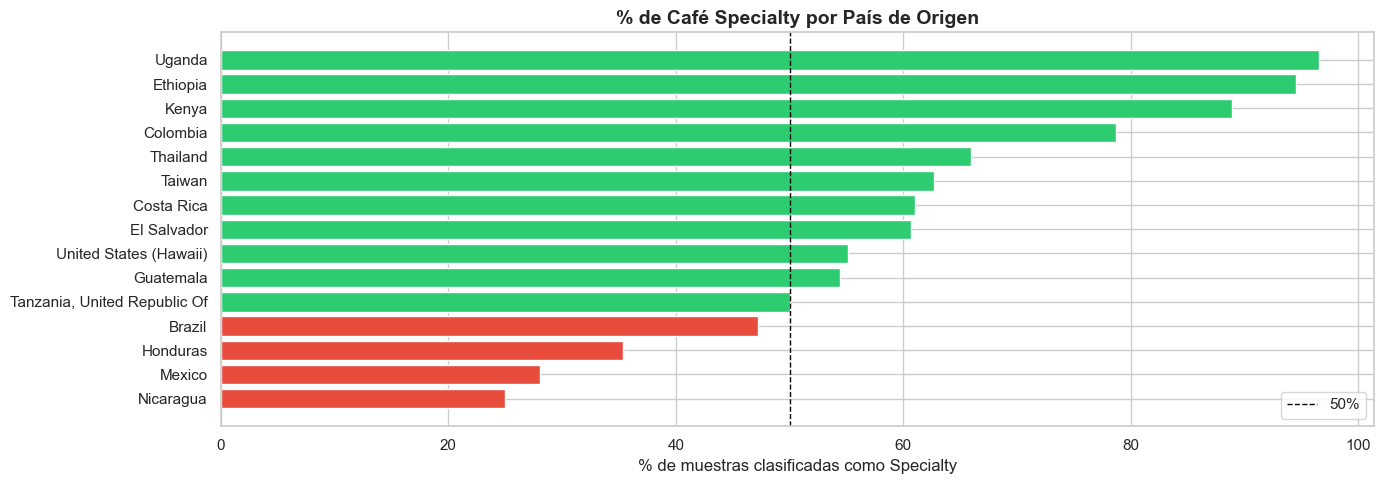

In [25]:
# ─── TASA DE SPECIALTY POR PAÍS ───────────────────────────────────────────────
# ¿Hay países donde una mayor proporción de su café es Specialty?

if col_pais in df_clean.columns:
    # Calcular el % de Specialty por país (solo países con +50 muestras para ser significativos)

    paises_validos = df_clean[col_pais].value_counts()
    paises_validos = paises_validos[paises_validos >= 25].index

    tasa_specialty = (
        df_clean[df_clean[col_pais].isin(paises_validos)]
        .groupby(col_pais)['quality_label']
        .apply(lambda x: (x == 'Specialty').mean() * 100)
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(14, 5))
    colors_bar = ['#2ecc71' if v >= 50 else '#e74c3c' for v in tasa_specialty.values[::-1]]
    bars = plt.barh(tasa_specialty.index[::-1], tasa_specialty.values[::-1],
                    color=colors_bar, edgecolor='white')
    
    plt.axvline(50, color='black', linestyle='--', linewidth=1, label='50%')
    plt.xlabel('% de muestras clasificadas como Specialty')
    plt.title('% de Café Specialty por País de Origen', fontsize=14, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()

Filtramos a los países que tienen más de 25 muestras para calcular la tasa de Specialty de manera correcta. Ya que si un país tienen solo 2 muestras y son Specialty tendría un 100%, pero con un tamaño de muestra insuficiente.


📊 Diagnóstico de altitud:
  Total filas:                    1512
  Nulos / no parseables:          260 (17.2%)
  Valor mínimo (antes filtro):    100 m
  Valor máximo (antes filtro):    3500 m
  Descartados por rango imposible: 0 (0.0%)
  Filas válidas para análisis:     1512


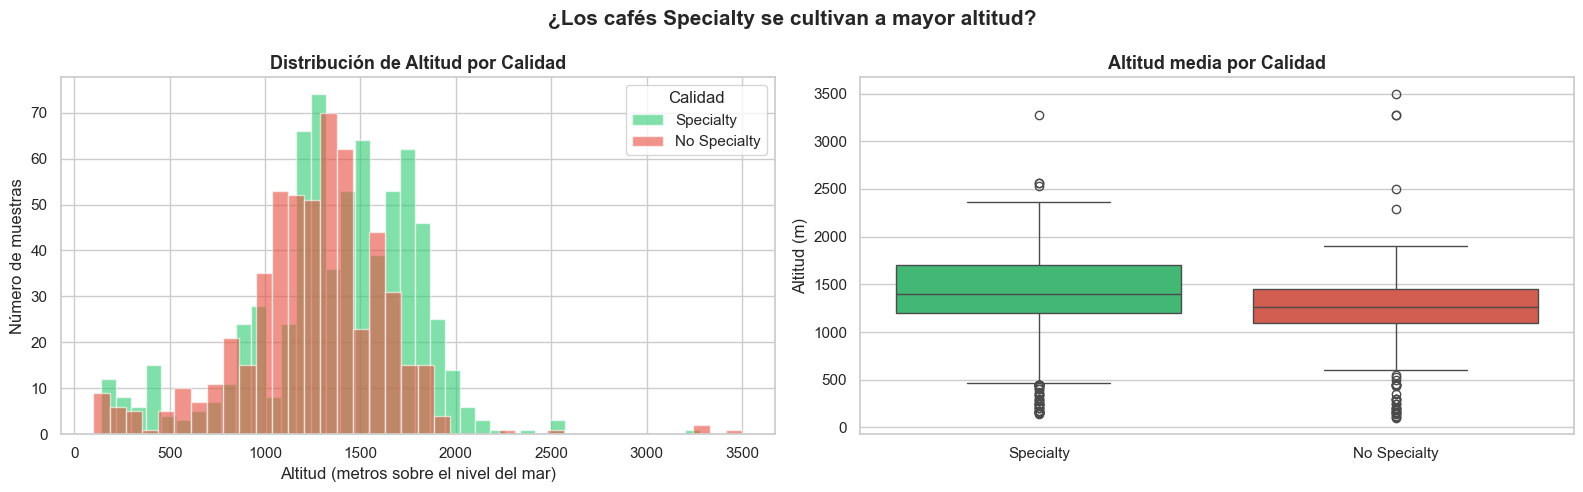


☕ Altitud media — Specialty:    1377 m
☕ Altitud media — No Specialty: 1248 m
📌 Diferencia:                   129 m


In [28]:
# ─── ANÁLISIS DE ALTITUD ───────────────────────────────────────────────────────
Altitude = 'altitud_limpia' 

if Altitude in df_clean.columns:

    # Diagnóstico antes de filtrar
    total = len(df_clean)
    nulos_alt = df_clean['altitud_limpia'].isna().sum()
    print(f'\n📊 Diagnóstico de altitud:')
    print(f'  Total filas:                    {total}')
    print(f'  Nulos / no parseables:          {nulos_alt} ({nulos_alt/total*100:.1f}%)')
    print(f'  Valor mínimo (antes filtro):    {df_clean["altitud_limpia"].min():.0f} m')
    print(f'  Valor máximo (antes filtro):    {df_clean["altitud_limpia"].max():.0f} m')

    # Filtrar altitudes imposibles ( 100m / 3500m son errores de datos)
    df_altitud = df_clean.copy()

    descartados = total - len(df_altitud)
    print(f'  Descartados por rango imposible: {descartados} ({descartados/total*100:.1f}%)')
    print(f'  Filas válidas para análisis:     {len(df_altitud)}')

    # ─── GRÁFICO 1: Histograma altitud por calidad ────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for label, color in palette.items():
        subset = df_altitud[df_altitud['quality_label'] == label]['altitud_limpia']
        axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='white')

    axes[0].set_xlabel('Altitud (metros sobre el nivel del mar)')
    axes[0].set_ylabel('Número de muestras')
    axes[0].set_title('Distribución de Altitud por Calidad', fontsize=13, fontweight='bold')
    axes[0].legend(title='Calidad')

    # ─── GRÁFICO 2: Boxplot altitud por calidad ───────────────────────────────
    sns.boxplot(
        data=df_altitud, x='quality_label', y='altitud_limpia',
        palette=palette, ax=axes[1], order=['Specialty', 'No Specialty']
    )
    axes[1].set_title('Altitud media por Calidad', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Altitud (m)')

    plt.suptitle('¿Los cafés Specialty se cultivan a mayor altitud?', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


    # Estadísticas finales
    media_s  = df_altitud[df_altitud['quality_label']=='Specialty']['altitud_limpia'].mean()
    media_ns = df_altitud[df_altitud['quality_label']=='No Specialty']['altitud_limpia'].mean()
    print(f'\n☕ Altitud media — Specialty:    {media_s:.0f} m')
    print(f'☕ Altitud media — No Specialty: {media_ns:.0f} m')
    print(f'📌 Diferencia:                   {abs(media_s - media_ns):.0f} m')

else:
    print('⚠️  No se encontró columna de altitud.')
    print(f'Columnas disponibles: {list(df_clean.columns)}')


El filtro de 100m a 3500m es razonable ya que el café crece entre ~500m y ~3000m típicamente. Valores fuera de ese rango son errores de transcripción.

Esto confirma la regla del café de especialidad: a mayor altitud, los granos maduran más lento y desarrollan más complejidad. Los 129 metros de diferencia son una señal débil pero existente.

---
## 🔥 BLOQUE 6 — Matriz de correlación

**¿Qué es la correlación?**  
Mide cuánto se relacionan dos variables numéricas entre sí.  
- Correlación `+1` → cuando una sube, la otra también sube (relación perfecta positiva)  
- Correlación `-1` → cuando una sube, la otra baja (relación perfecta negativa)  
- Correlación `0` → no hay relación

**¿Para qué sirve en ML?**
- Identificar qué variables tienen más relación con el target
- Detectar variables muy correlacionadas entre sí (redundantes) — puede ser mejor eliminar una

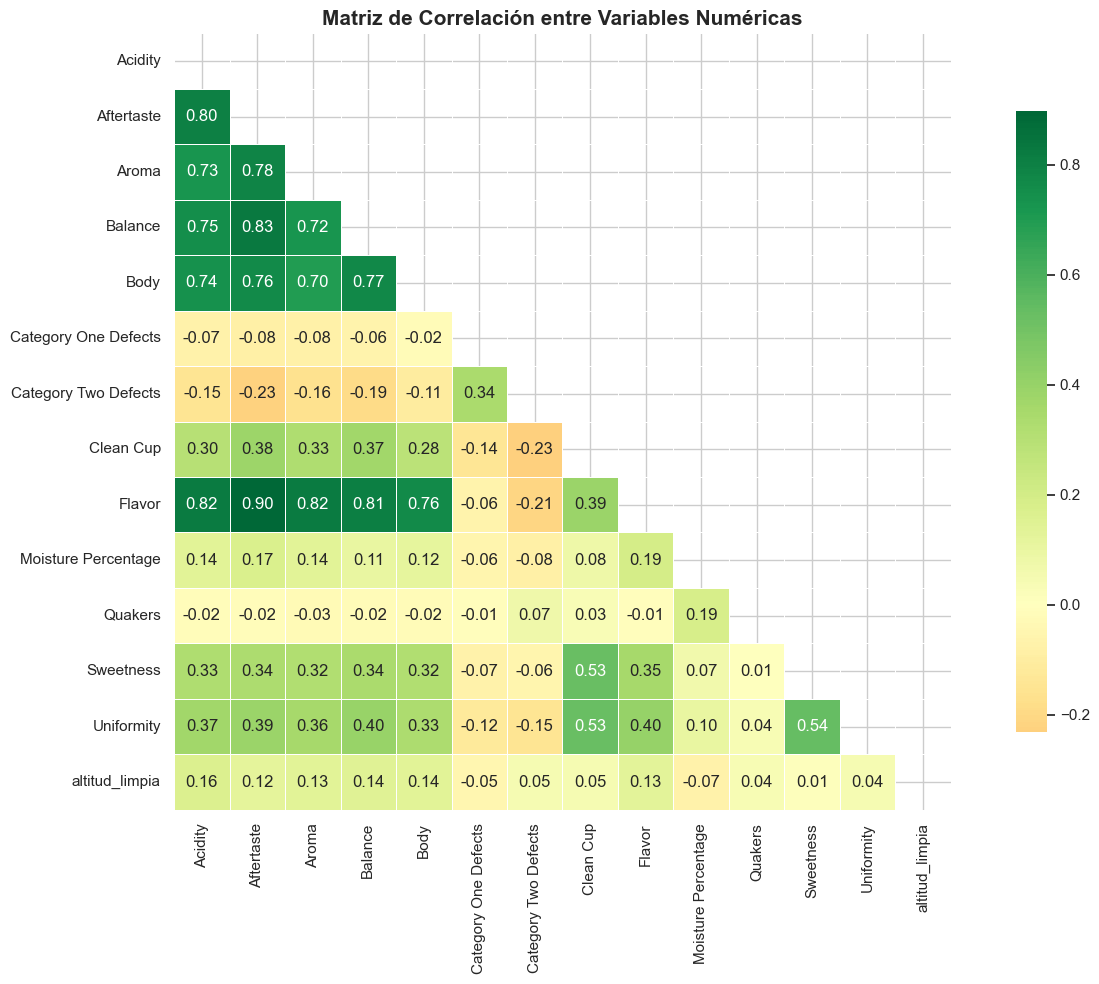

In [29]:
# ─── HEATMAP DE CORRELACIÓN ───────────────────────────────────────────────────
# Solo calculamos correlación entre columnas numéricas

numericas = df_clean.select_dtypes(include=[np.number])
correlacion = numericas.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlacion, dtype=bool))  # Mostrar solo triángulo inferior

sns.heatmap(
    correlacion,
    mask=mask,
    annot=True,           # Mostrar valores numéricos
    fmt='.2f',            # 2 decimales
    cmap='RdYlGn',        # Verde=positivo, Rojo=negativo
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

⚠️ Limitación importante: La correlación de Pearson asume relaciones lineales. Si una variable tiene relación no lineal con el target, la correlación puede ser baja aunque sea predictiva. Por eso la correlación es una señal orientativa, no definitiva.

El gráfico muestra posible correlación entre variables, se tendrá que estudiar cuando se entrene el modelo con regresión logística.

---
## 🎯 BLOQUE 7 — Detección de Outliers

El gráfico del bloque 4 muestra los Outliers de manera gráfica, ahora los calcularemos para saber cuantos existen en realidad.

**¿Por qué importa?**  
Los outliers pueden distorsionar el modelo, haciéndolo aprender de casos excepcionales en lugar de la norma.

**Método IQR:**  
Se considera outlier cualquier valor fuera del rango `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`

In [31]:
# ─── CUANTIFICAR OUTLIERS CON EL MÉTODO IQR ───────────────────────────────────

print('📊 Resumen de Outliers por Variable:\n')
print(f'{"Variable":<20} {"Q1":>8} {"Q3":>8} {"IQR":>8} {"Outliers":>10} {"% del total":>12}')
print('-' * 70)

for var in variables_sensoriales:
    Q1 = df_clean[var].quantile(0.25)
    Q3 = df_clean[var].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = ((df_clean[var] < limite_inf) | (df_clean[var] > limite_sup)).sum()
    pct = n_outliers / len(df_clean) * 100
    print(f'{var:<20} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {n_outliers:>10} {pct:>11.2f}%')

📊 Resumen de Outliers por Variable:

Variable                   Q1       Q3      IQR   Outliers  % del total
----------------------------------------------------------------------
Aroma                    7.42     7.75     0.33         79        5.22%
Flavor                   7.33     7.75     0.42         46        3.04%
Aftertaste               7.25     7.67     0.42         45        2.98%
Acidity                  7.33     7.75     0.42         26        1.72%
Body                     7.33     7.75     0.42         15        0.99%
Balance                  7.33     7.75     0.42         41        2.71%
Uniformity              10.00    10.00     0.00        185       12.24%
Sweetness               10.00    10.00     0.00         93        6.15%


¿Se deben eliminar? Depende del contexto. Si los outliers son errores de medición, se eliminan. Si son casos reales pero excepcionales (un café realmente malo en textura), conservarlos puede ayudar al modelo a aprender esos casos límite.

---
## ✅ BLOQUE 8 — Conclusiones del EDA y próximos pasos

### 📝 Conclusiones — completar con vuestros hallazgos


In [33]:
# ─── GUARDAR EL DATASET LIMPIO PARA EL SIGUIENTE NOTEBOOK ────────────────────
# Este CSV limpio será el punto de partida del notebook de preprocesamiento y modelado
df_clean.to_csv('../data/processed/EDA_coffee_quality_fusion.csv', index=False)

print('✅ Dataset guardado en: ../data/processed/EDA_coffee_quality_fusion.csv')
print(f'📊 Dimensiones finales: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas')
print(f'🎯 Distribución final del target:')
print(df_clean['quality_label'].value_counts())

✅ Dataset guardado en: ../data/processed/EDA_coffee_quality_fusion.csv
📊 Dimensiones finales: 1512 filas x 23 columnas
🎯 Distribución final del target:
quality_label
Specialty       834
No Specialty    678
Name: count, dtype: int64
